# Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) is a supervised dimensionality
reduction technique.

LDA transforms the original features into a smaller number of new
features while trying to maximize the separation between different
classes.

Unlike PCA, LDA uses the target variable.

LDA is mainly used for:

- Dimensionality Reduction
- Classification
- Data Visualization
- Class Separation

## PCA vs LDA

### PCA

PCA is an unsupervised technique.

It tries to maximize:

**Variance**

PCA does not use the target variable.

### LDA

LDA is a supervised technique.

It tries to maximize:

**Separation between classes**

LDA uses the target variable.

Therefore:

PCA → Maximum Variance

LDA → Maximum Class Separation

## LDA Intuition

Suppose we have two classes:

Class 0 → ● ● ● ●

Class 1 → ▲ ▲ ▲ ▲

LDA searches for a projection that keeps the two classes as separated
as possible.

The goal is:

Large distance between class means

and

Small variation within each class

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="Target"
)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [2]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Target, dtype: int64

## Feature Scaling

Scaling is commonly applied before dimensionality reduction.

Standardization transforms features so that they have approximately:

Mean = 0

Standard Deviation = 1

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## Applying LDA

Scikit-learn provides the `LinearDiscriminantAnalysis` class.

LDA requires:

- Feature matrix X
- Target variable y

This is because LDA is supervised and uses class labels.

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

X_lda.shape

(150, 2)

In [5]:
lda_df = pd.DataFrame(
    X_lda,
    columns=["LD1", "LD2"]
)

lda_df.head()

,LD1,LD2
0,8.061800,-0.300421
1,7.128688,0.786660
2,7.489828,0.265384
3,6.813201,0.670631
4,8.132309,-0.514463


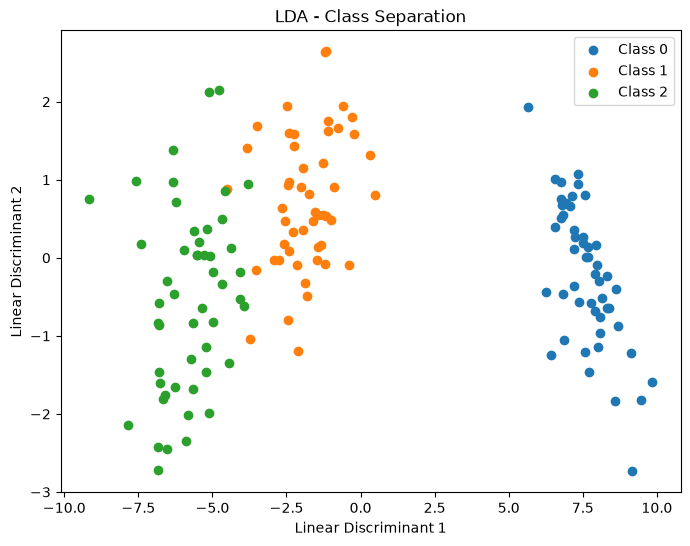

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for class_value in sorted(y.unique()):
    
    plt.scatter(
        X_lda[y == class_value, 0],
        X_lda[y == class_value, 1],
        label=f"Class {class_value}"
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("LDA - Class Separation")
plt.legend()

plt.show()

## Explained Variance Ratio

LDA provides an `explained_variance_ratio_` attribute.

It tells us how much of the class-separating information is captured
by each linear discriminant.

The values can be used to understand the contribution of each
discriminant component.

In [7]:
lda.explained_variance_ratio_

array([0.9912126, 0.0087874])

In [8]:
import numpy as np

cumulative_variance = np.cumsum(
    lda.explained_variance_ratio_
)

cumulative_variance

array([0.9912126, 1.       ])

## LDA Components

Each Linear Discriminant is a combination of the original features.

The coefficients indicate how strongly each original feature contributes
to the discriminant.

In [9]:
lda.coef_

array([[  5.21157831,   5.27345252, -29.81560843, -15.77885735],
       [ -1.26370067,  -1.90100128,   8.26157263,   2.32662354],
       [ -3.94787765,  -3.37245124,  21.5540358 ,  13.45223381]])

In [10]:
lda_coefficients = pd.DataFrame(
    lda.coef_,
    columns=X.columns
)

lda_coefficients

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.211578,5.273453,-29.815608,-15.778857
1,-1.263701,-1.901001,8.261573,2.326624
2,-3.947878,-3.372451,21.554036,13.452234


## Number of LDA Components

The maximum number of LDA components is:

min(number of features, number of classes - 1)

For example:

If we have 4 features and 3 classes:

Maximum components = min(4, 3 - 1)

Maximum components = 2

## Binary Classification

For two classes:

Number of classes = 2

Maximum LDA components:

2 - 1 = 1

Therefore, binary classification can have at most one linear discriminant.

## LDA for Classification

LDA can also be used directly as a classification algorithm.

It estimates the probability that an observation belongs to each class
and assigns the observation to the most likely class.

Therefore, LDA has two common uses:

1. Dimensionality Reduction
2. Classification

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lda_classifier = LinearDiscriminantAnalysis()

lda_classifier.fit(
    X_train,
    y_train
)

y_pred = lda_classifier.predict(X_test)

y_pred[:10]

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1])

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 1.0
